In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
df=pd.read_csv('IPL IMB381IPL2013.csv')
df.columns


Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

In [5]:


X_features = ['AGE','COUNTRY','PLAYING ROLE',
              'T-RUNS','T-WKTS','ODI-RUNS-S','ODI-SR-B','ODI-WKTS','ODI-SR-BL',
              'CAPTAINCY EXP','RUNS-S','HS','AVE','SR-B','SIXERS','RUNS-C',
              'WKTS','AVE-BL','ECON','SR-BL']
categorical_features = ['AGE','COUNTRY','PLAYING ROLE','CAPTAINCY EXP']
df1=pd.get_dummies(df[X_features], columns=categorical_features, drop_first=True)
df1.columns

Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
       'ECON', 'SR-BL', 'AGE_2', 'AGE_3', 'COUNTRY_BAN', 'COUNTRY_ENG',
       'COUNTRY_IND', 'COUNTRY_NZ', 'COUNTRY_PAK', 'COUNTRY_SA', 'COUNTRY_SL',
       'COUNTRY_WI', 'COUNTRY_ZIM', 'PLAYING ROLE_Batsman',
       'PLAYING ROLE_Bowler', 'PLAYING ROLE_W. Keeper', 'CAPTAINCY EXP_1'],
      dtype='object')

In [6]:
x=df1
y=df['SOLD PRICE']
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=sc.fit_transform(x)
Y=(y-y.mean())/y.std()
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,Y_train)
LinearRegression(copy_X=True,fit_intercept=True,n_jobs=1)

print(lr.coef_)


[-0.43539611 -0.04632556  0.50840867 -0.03323988  0.2220377  -0.05065703
  0.17282657 -0.49173336  0.58571405 -0.11654753  0.24880095  0.09546057
  0.16428731  0.26400753 -0.08253341 -0.28643889 -0.26842214 -0.21910913
 -0.02622351  0.24817898  0.18760332  0.10776084  0.04737488  0.05191335
  0.01235245  0.00547115 -0.03124706  0.08530192  0.01790803 -0.05077454
  0.18745577]


In [9]:
Columns_coef_df=pd.DataFrame({'columns':df1.columns, 'coef':lr.coef_})
sorted_coef_vals=Columns_coef_df.sort_values('coef',ascending=False)
print(sorted_coef_vals)

                   columns      coef
8                      AVE  0.585714
2               ODI-RUNS-S  0.508409
13                  AVE-BL  0.264008
10                  SIXERS  0.248801
19             COUNTRY_ENG  0.248179
4                 ODI-WKTS  0.222038
20             COUNTRY_IND  0.187603
30         CAPTAINCY EXP_1  0.187456
6                   RUNS-S  0.172827
12                    WKTS  0.164287
21              COUNTRY_NZ  0.107761
11                  RUNS-C  0.095461
27    PLAYING ROLE_Batsman  0.085302
23              COUNTRY_SA  0.051913
22             COUNTRY_PAK  0.047375
28     PLAYING ROLE_Bowler  0.017908
24              COUNTRY_SL  0.012352
25              COUNTRY_WI  0.005471
18             COUNTRY_BAN -0.026224
26             COUNTRY_ZIM -0.031247
3                 ODI-SR-B -0.033240
1                   T-WKTS -0.046326
5                ODI-SR-BL -0.050657
29  PLAYING ROLE_W. Keeper -0.050775
14                    ECON -0.082533
9                     SR-B -0.116548
1

Text(0.5, 0, 'Coefficient from Linear Regression')

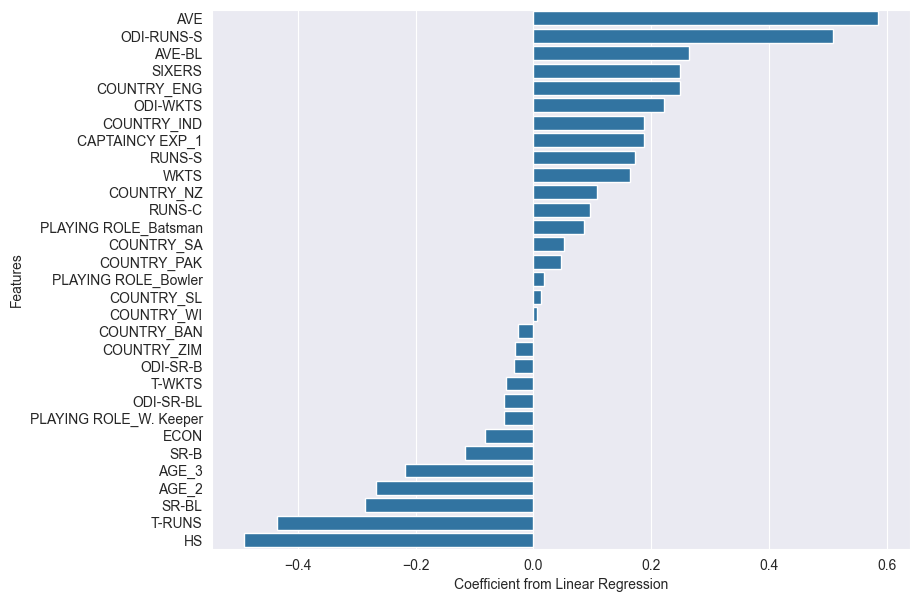

In [10]:
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize = (9, 7))
sn.barplot(x="coef",y="columns",data=sorted_coef_vals)

plt.ylabel("Features")
plt.xlabel("Coefficient from Linear Regression")


In [15]:
from sklearn import metrics
def get_train_test_RMSE (model):
    Y_train_pred=model.predict(X_train)
    rmse_train=round(np.sqrt(metrics.mean_squared_error(Y_train,Y_train_pred)),3)
    Y_test_pred=model.predict(X_test)
    rmse_test=round(np.sqrt(metrics.mean_squared_error(Y_test,Y_test_pred)),3)
    print("Train: ",rmse_train,"Test: ",rmse_test)

In [16]:
get_train_test_RMSE(lr)

Train:  0.679 Test:  0.749


In [17]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1,max_iter=500)
ridge.fit(X_train,Y_train)
get_train_test_RMSE(ridge)

Train:  0.68 Test:  0.724


In [19]:
ridge=Ridge(alpha=2.0, max_iter=1000)
ridge.fit(X_train,Y_train)
get_train_test_RMSE(ridge)

Train:  0.682 Test:  0.706


In [20]:
from sklearn.linear_model import Lasso
las=Lasso(alpha=0.01,max_iter=500)
las.fit(X_train,Y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",500
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [23]:
get_train_test_RMSE(las)
las_df=pd.DataFrame({'coumns':df1.columns,'values':df1.columns, 'coef': las.coef_})
las_df[las_df.coef==0]

Train:  0.688 Test:  0.698


,coumns,values,coef
1,T-WKTS,T-WKTS,-0.0
3,ODI-SR-B,ODI-SR-B,-0.0
13,AVE-BL,AVE-BL,-0.0
28,PLAYING ROLE_Bowler,PLAYING ROLE_Bowler,0.0


In [29]:
from sklearn.linear_model import ElasticNet
e = ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=500)
e.fit(X_train,Y_train)
get_train_test_RMSE(e)


Train:  0.681 Test:  0.721


In [34]:
Y_test = Y_test.astype(int)
from sklearn.metrics import confusion_matrix

y_pred = e.predict(X_test)
y_pred_class = (y_pred >= 0.5).astype(int)

Y_test = Y_test.astype(int)   

cm = confusion_matrix(Y_test, y_pred_class)
print(cm)

[[ 0  1  0  0]
 [ 0 16  7  0]
 [ 0  1  0  0]
 [ 0  0  1  0]]


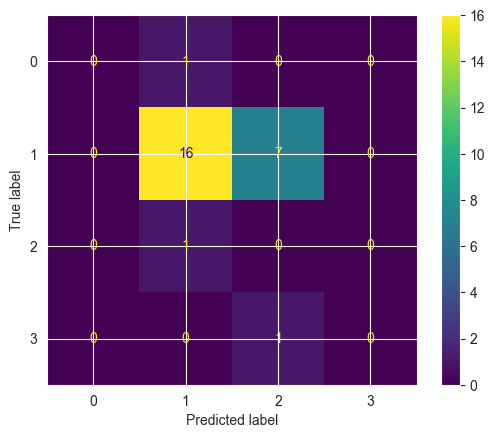

In [35]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()